In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install datasets imbalanced-learn -q
print("Kurulum tamam ✅")

Kurulum tamam ✅


In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("fthbrmnby/turkish_product_reviews")
df = pd.DataFrame(dataset['train'])

print(f"Toplam yorum: {len(df)}")
print(df['sentiment'].value_counts())

README.md:   0%|          | 0.00/3.84k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/24.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/235165 [00:00<?, ? examples/s]

Toplam yorum: 235165
sentiment
1    220284
0     14881
Name: count, dtype: int64


In [ ]:
import re

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['sentence'] = df['sentence'].apply(preprocess)
df = df[df['sentence'].apply(lambda x: len(x.split()) >= 2)].reset_index(drop=True)

print(f"Toplam yorum: {len(df)}")
print(f"Olumlu: {sum(df['sentiment']==1)}")
print(f"Olumsuz: {sum(df['sentiment']==0)}")

Toplam yorum: 234100
Olumlu: 219320
Olumsuz: 14780


In [ ]:
from sklearn.model_selection import train_test_split

X = df['sentence']
y = df['sentiment'].values

# Önce %80 train+val, %20 test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sonra train+val'ı %75 train, %25 val olarak böl
# (toplamın %60'ı train, %20'si val, %20'si test)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Train seti: {len(y_train)} yorum")
print(f"Validation seti: {len(y_val)} yorum")
print(f"Test seti: {len(y_test)} yorum")
print(f"\nTrain - Olumlu: {sum(y_train==1)}, Olumsuz: {sum(y_train==0)}")
print(f"Val   - Olumlu: {sum(y_val==1)}, Olumsuz: {sum(y_val==0)}")
print(f"Test  - Olumlu: {sum(y_test==1)}, Olumsuz: {sum(y_test==0)}")

Train seti: 140460 yorum
Validation seti: 46820 yorum
Test seti: 46820 yorum

Train - Olumlu: 131592, Olumsuz: 8868
Val   - Olumlu: 43864, Olumsuz: 2956
Test  - Olumlu: 43864, Olumsuz: 2956


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# Word TF-IDF
word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    min_df=2
)

# Char n-gram
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=50000,
    sublinear_tf=True
)

# Sadece train üzerinde fit et
X_train_word = word_vectorizer.fit_transform(X_train)
X_train_char = char_vectorizer.fit_transform(X_train)

# Val ve test için sadece transform
X_val_word = word_vectorizer.transform(X_val)
X_val_char = char_vectorizer.transform(X_val)
X_test_word = word_vectorizer.transform(X_test)
X_test_char = char_vectorizer.transform(X_test)

# Birleştir
X_train_combined = sp.hstack([X_train_word, X_train_char])
X_val_combined = sp.hstack([X_val_word, X_val_char])
X_test_combined = sp.hstack([X_test_word, X_test_char])

print(f"Train feature matrisi: {X_train_combined.shape} ✅")
print(f"Val feature matrisi: {X_val_combined.shape} ✅")
print(f"Test feature matrisi: {X_test_combined.shape} ✅")

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
import time

# SMOTE sadece train setine uygula
print("SMOTE uygulanıyor...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_combined, y_train)

print(f"Önce: {sum(y_train==1)} olumlu, {sum(y_train==0)} olumsuz")
print(f"Sonra: {sum(y_train_smote==1)} olumlu, {sum(y_train_smote==0)} olumsuz")

# Model eğit
print("\nModel eğitimi başlıyor...")
start = time.time()
model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
model.fit(X_train_smote, y_train_smote)
end = time.time()
print(f"Eğitim tamamlandı! ✅ ({round(end-start, 2)} saniye)")

SMOTE uygulanıyor...
Önce: 131592 olumlu, 8868 olumsuz
Sonra: 131592 olumlu, 131592 olumsuz

Model eğitimi başlıyor...
Eğitim tamamlandı! ✅ (38.67 saniye)


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# Validation seti üzerinde olasılık tahminleri
y_val_proba = model.predict_proba(X_val_combined)[:, 1]

# Farklı threshold değerleri dene
print("="*50)
print("VALIDATION SETİNDE THRESHOLD KARŞILAŞTIRMASI")
print("="*50)

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.05):
    y_pred_val = (y_val_proba >= threshold).astype(int)
    olumsuz_f1 = f1_score(y_val, y_pred_val, pos_label=0)
    acc = accuracy_score(y_val, y_pred_val)
    print(f"Threshold: {threshold:.2f} → Accuracy: {acc:.4f}, Olumsuz F1: {olumsuz_f1:.4f}")

    if olumsuz_f1 > best_f1:
        best_f1 = olumsuz_f1
        best_threshold = threshold

print(f"\n✅ En iyi threshold: {best_threshold:.2f} (Olumsuz F1: {best_f1:.4f})")

VALIDATION SETİNDE THRESHOLD KARŞILAŞTIRMASI
Threshold: 0.10 → Accuracy: 0.9562, Olumsuz F1: 0.5388
Threshold: 0.15 → Accuracy: 0.9572, Olumsuz F1: 0.5805
Threshold: 0.20 → Accuracy: 0.9565, Olumsuz F1: 0.6023
Threshold: 0.25 → Accuracy: 0.9548, Olumsuz F1: 0.6139
Threshold: 0.30 → Accuracy: 0.9521, Olumsuz F1: 0.6128
Threshold: 0.35 → Accuracy: 0.9495, Olumsuz F1: 0.6149
Threshold: 0.40 → Accuracy: 0.9459, Olumsuz F1: 0.6115
Threshold: 0.45 → Accuracy: 0.9417, Olumsuz F1: 0.6026
Threshold: 0.50 → Accuracy: 0.9360, Olumsuz F1: 0.5896
Threshold: 0.55 → Accuracy: 0.9291, Olumsuz F1: 0.5725
Threshold: 0.60 → Accuracy: 0.9207, Olumsuz F1: 0.5534
Threshold: 0.65 → Accuracy: 0.9106, Olumsuz F1: 0.5327
Threshold: 0.70 → Accuracy: 0.8987, Olumsuz F1: 0.5086
Threshold: 0.75 → Accuracy: 0.8814, Olumsuz F1: 0.4751
Threshold: 0.80 → Accuracy: 0.8592, Olumsuz F1: 0.4389
Threshold: 0.85 → Accuracy: 0.8279, Olumsuz F1: 0.3979

✅ En iyi threshold: 0.35 (Olumsuz F1: 0.6149)


FİNAL TEST SONUÇLARI (Threshold: 0.35)
Accuracy:  0.9485
Macro F1:  0.7908

Detaylı Rapor:
              precision    recall  f1-score   support

     Olumsuz       0.58      0.64      0.61      2956
      Olumlu       0.98      0.97      0.97     43864

    accuracy                           0.95     46820
   macro avg       0.78      0.80      0.79     46820
weighted avg       0.95      0.95      0.95     46820



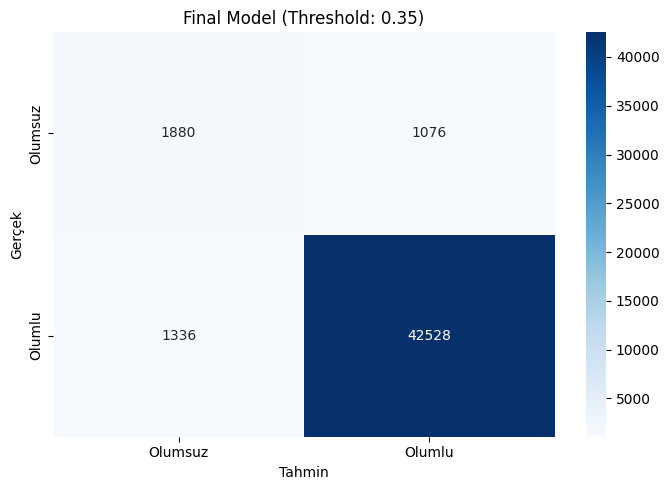

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Test seti üzerinde tahmin
y_test_proba = model.predict_proba(X_test_combined)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("="*50)
print(f"FİNAL TEST SONUÇLARI (Threshold: {best_threshold:.2f})")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Macro F1:  {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print("\nDetaylı Rapor:")
print(classification_report(y_test, y_test_pred, target_names=['Olumsuz', 'Olumlu']))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Olumsuz', 'Olumlu'],
            yticklabels=['Olumsuz', 'Olumlu'])
plt.title(f'Final Model (Threshold: {best_threshold:.2f})')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import numpy as np

print("5-fold Cross Validation başlıyor... (biraz sürebilir)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    X_train_combined,
    y_train,
    cv=skf,
    scoring=['accuracy', 'f1_macro', 'f1_weighted'],
    n_jobs=-1
)

print("\n" + "="*50)
print("5-FOLD CROSS VALIDATION SONUÇLARI")
print("="*50)
print(f"Accuracy:    {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"Macro F1:    {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")
print(f"Weighted F1: {scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}")

5-fold Cross Validation başlıyor... (biraz sürebilir)

5-FOLD CROSS VALIDATION SONUÇLARI
Accuracy:    0.9557 ± 0.0006
Macro F1:    0.7475 ± 0.0047
Weighted F1: 0.9478 ± 0.0008


In [ ]:
import pandas as pd

# Yanlış tahmin edilen olumsuz yorumları bul
X_test_list = X_test.tolist()
hatalar = []

for metin, gercek, tahmin in zip(X_test_list, y_test, y_test_pred):
    if gercek == 0 and tahmin == 1:
        hatalar.append({'yorum': metin})

df_hatalar = pd.DataFrame(hatalar)

# Kategorilere ayır
def kategorize(yorum):
    yorum = str(yorum).lower()

    # Olumsuzlama
    olumsuzlama = ['değil', 'yok', 'hiç', 'olmaz', 'olmadı', 'etmedi', 'vermedi']
    if any(k in yorum for k in olumsuzlama):
        return 'Olumsuzlama'

    # Kısa yorum
    if len(yorum.split()) <= 4:
        return 'Kısa Yorum'

    # Karma duygu
    olumlu = ['iyi', 'güzel', 'kaliteli', 'mükemmel', 'harika', 'süper']
    olumsuz = ['kötü', 'berbat', 'rezalet', 'pahalı', 'bozuk', 'yavaş']
    if any(o in yorum for o in olumlu) and any(k in yorum for k in olumsuz):
        return 'Karma Duygu'

    # Yazım bozukluğu
    if len([w for w in yorum.split() if len(w) > 15]) > 0:
        return 'Yazım Bozukluğu'

    return 'Bağlamsal/Diğer'

df_hatalar['kategori'] = df_hatalar['yorum'].apply(kategorize)

print("="*40)
print("HATA ANALİZİ KATEGORİLERİ")
print("="*40)
print(df_hatalar['kategori'].value_counts())
print(f"\nToplam hatalı yorum: {len(df_hatalar)}")

HATA ANALİZİ KATEGORİLERİ
kategori
Bağlamsal/Diğer    642
Olumsuzlama        283
Yazım Bozukluğu     86
Kısa Yorum          55
Karma Duygu         10
Name: count, dtype: int64

Toplam hatalı yorum: 1076


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


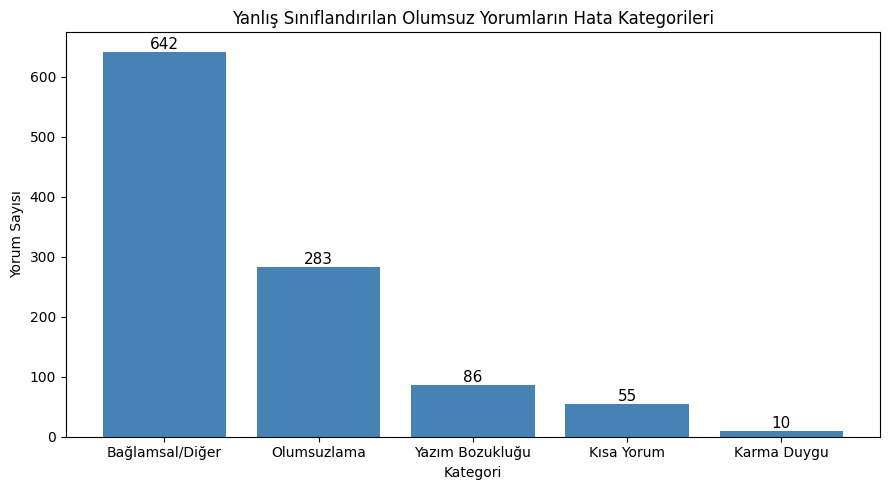

Kaydedildi ✅


In [ ]:
import matplotlib.pyplot as plt

kategori_sayilari = df_hatalar['kategori'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(kategori_sayilari.index, kategori_sayilari.values, color='steelblue')
plt.title('Yanlış Sınıflandırılan Olumsuz Yorumların Hata Kategorileri')
plt.xlabel('Kategori')
plt.ylabel('Yorum Sayısı')

for bar, val in zip(bars, kategori_sayilari.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hata_analizi_kategoriler.png', dpi=150)
plt.show()
print("Kaydedildi ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


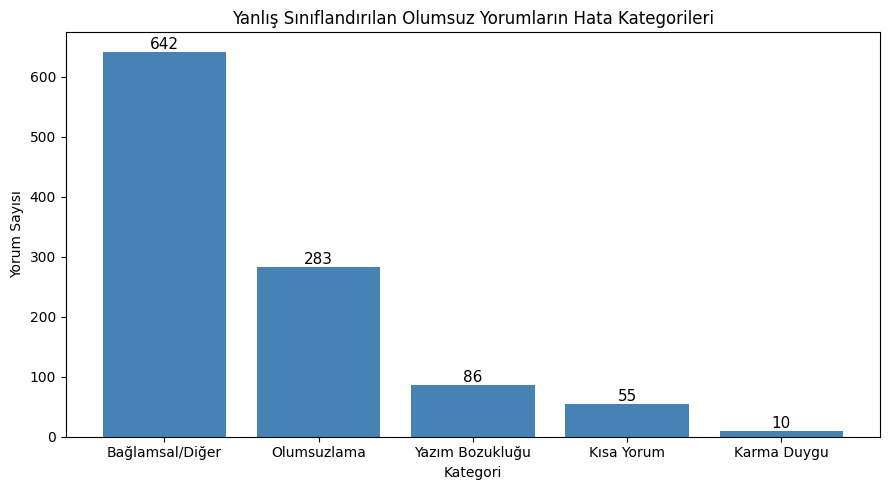

Kaydedildi ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

plt.figure(figsize=(9, 5))
bars = plt.bar(kategori_sayilari.index, kategori_sayilari.values, color='steelblue')
plt.title('Yanlış Sınıflandırılan Olumsuz Yorumların Hata Kategorileri')
plt.xlabel('Kategori')
plt.ylabel('Yorum Sayısı')

for bar, val in zip(bars, kategori_sayilari.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hata_analizi_kategoriler.png', dpi=150)
plt.show()
print("Kaydedildi ✅")

In [ ]:
import joblib

joblib.dump(model, '/content/drive/MyDrive/final_smote_lr_model.pkl')
joblib.dump(word_vectorizer, '/content/drive/MyDrive/final_word_vectorizer.pkl')
joblib.dump(char_vectorizer, '/content/drive/MyDrive/final_char_vectorizer.pkl')
df_hatalar.to_csv('/content/drive/MyDrive/hata_analizi_kategorili.csv', index=False)

print("Final model kaydedildi ✅")
print("Word vectorizer kaydedildi ✅")
print("Char vectorizer kaydedildi ✅")
print("Hata analizi kaydedildi ✅")
print(f"\nKullanılacak threshold: {best_threshold:.2f}")

Final model kaydedildi ✅
Word vectorizer kaydedildi ✅
Char vectorizer kaydedildi ✅
Hata analizi kaydedildi ✅

Kullanılacak threshold: 0.35


In [ ]:
!pip install transformers torch -q
print("Kurulum tamam ✅")

Kurulum tamam ✅


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import torch

print("GPU var mı:", torch.cuda.is_available())

model_name = "dbmdz/bert-base-turkish-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Tokenizer yüklendi ✅")
print(f"Model: {model_name}")

GPU var mı: False


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/263k [00:00<?, ?B/s]

Tokenizer yüklendi ✅
Model: dbmdz/bert-base-turkish-uncased


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# BERT için küçük alt küme (3000 olumlu + 3000 olumsuz)
df_bert_pos = df[df['sentiment'] == 1].sample(n=3000, random_state=42)
df_bert_neg = df[df['sentiment'] == 0].sample(n=3000, random_state=42)
df_bert = pd.concat([df_bert_pos, df_bert_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

X_bert_train, X_bert_test, y_bert_train, y_bert_test = train_test_split(
    df_bert['sentence'].tolist(),
    df_bert['sentiment'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_bert['sentiment']
)

print(f"BERT Train: {len(X_bert_train)} yorum")
print(f"BERT Test: {len(X_bert_test)} yorum")
print(f"Olumlu: {sum(y_bert_test)}, Olumsuz: {len(y_bert_test)-sum(y_bert_test)}")

BERT Train: 4800 yorum
BERT Test: 1200 yorum
Olumlu: 600, Olumsuz: 600


In [ ]:
import torch
from torch.utils.data import Dataset

# Tüm veriyi kullanalım
X_bert_train = X_train.tolist()
X_bert_val = X_val.tolist()
X_bert_test = X_test.tolist()

y_bert_train = y_train.tolist()
y_bert_val = y_val.tolist()
y_bert_test = y_test.tolist()

print(f"Train: {len(X_bert_train)} yorum")
print(f"Val: {len(X_bert_val)} yorum")
print(f"Test: {len(X_bert_test)} yorum")

Train: 140460 yorum
Val: 46820 yorum
Test: 46820 yorum


In [ ]:
!pip install datasets transformers torch -q
print("Kurulum tamam ✅")

Kurulum tamam ✅


In [ ]:
from datasets import load_dataset
import pandas as pd
import re
from sklearn.model_selection import train_test_split

dataset = load_dataset("fthbrmnby/turkish_product_reviews")
df = pd.DataFrame(dataset['train'])

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['sentence'] = df['sentence'].apply(preprocess)
df = df[df['sentence'].apply(lambda x: len(x.split()) >= 2)].reset_index(drop=True)

# Train, Val, Test böl
X = df['sentence']
y = df['sentiment'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Train: {len(X_train)} yorum ✅")
print(f"Val: {len(X_val)} yorum ✅")
print(f"Test: {len(X_test)} yorum ✅")

Train: 140460 yorum ✅
Val: 46820 yorum ✅
Test: 46820 yorum ✅


In [ ]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

model_name = "dbmdz/bert-base-turkish-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class TurkishReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TurkishReviewDataset(X_train.tolist(), y_train.tolist(), tokenizer)
val_dataset = TurkishReviewDataset(X_val.tolist(), y_val.tolist(), tokenizer)
test_dataset = TurkishReviewDataset(X_test.tolist(), y_test.tolist(), tokenizer)

print(f"Train dataset: {len(train_dataset)} ✅")
print(f"Val dataset: {len(val_dataset)} ✅")
print(f"Test dataset: {len(test_dataset)} ✅")

Train dataset: 140460 ✅
Val dataset: 46820 ✅
Test dataset: 46820 ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import EarlyStoppingCallback
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Modeli yükle
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2
)

# Metrik fonksiyonu
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')
    neg_f1 = f1_score(labels, predictions, pos_label=0)
    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'neg_f1': neg_f1
    }

# Eğitim ayarları
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/bert_checkpoints',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='neg_f1',
    logging_dir='/content/drive/MyDrive/bert_logs',
    logging_steps=100,
    warmup_steps=500,
    weight_decay=0.01,
)

# Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Eğitim başlıyor... (uzun sürebilir ☕)")
trainer.train()
print("Eğitim tamamlandı! ✅")

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

Eğitim başlıyor... (uzun sürebilir ☕)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
import os
checkpoint_dir = '/content/drive/MyDrive/berturk_checkpoints'
if os.path.exists(checkpoint_dir):
    print(os.listdir(checkpoint_dir))
else:
    print("Klasör bulunamadı")

In [ ]:
print(X_train_combined.shape)
print(y_train.shape)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

predictions = trainer.predict(test_dataset)
y_pred_bert = predictions.predictions.argmax(-1)

print("="*50)
print("BERT FİNAL TEST SONUÇLARI")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bert):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred_bert, average='macro'):.4f}")
print(classification_report(y_test, y_pred_bert, target_names=['Olumsuz', 'Olumlu']))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Olumsuz', 'Olumlu'],
            yticklabels=['Olumsuz', 'Olumlu'])
plt.title('BERTurk Final Model')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_bert.png', dpi=150)
plt.show()
print("Kaydedildi ✅")

In [ ]:
import pandas as pd
import numpy as np

# Yanlış tahmin edilen olumsuz yorumları bul
X_test_list = X_test.tolist()
hatalar = []

for metin, gercek, tahmin in zip(X_test_list, y_test, y_pred_bert):
    if gercek == 0 and tahmin == 1:
        hatalar.append({'yorum': metin})

df_hatalar = pd.DataFrame(hatalar)
print(f"Toplam hatalı yorum: {len(df_hatalar)} ✅")

In [ ]:
def kategorize(yorum):
    yorum = str(yorum).lower()

    # Olumsuzlama
    olumsuzlama = ['değil', 'yok', 'hiç', 'olmaz', 'olmadı', 'etmedi', 'vermedi']
    if any(k in yorum for k in olumsuzlama):
        return 'Olumsuzlama'

    # Kısa yorum
    if len(yorum.split()) <= 4:
        return 'Kısa Yorum'

    # Karma duygu
    olumlu = ['iyi', 'güzel', 'kaliteli', 'mükemmel', 'harika', 'süper']
    olumsuz = ['kötü', 'berbat', 'rezalet', 'pahalı', 'bozuk', 'yavaş']
    if any(o in yorum for o in olumlu) and any(k in yorum for k in olumsuz):
        return 'Karma Duygu'

    # İroni
    ironi = ['çok iyi', 'harika ya', 'mükemmel ya', 'bravo', 'helal',
             'tebrikler', 'süper işte', 'vallahi çok iyi']
    if any(k in yorum for k in ironi):
        return 'İroni'

    # Yazım bozukluğu
    if len([w for w in yorum.split() if len(w) > 15]) > 0:
        return 'Yazım Bozukluğu'

    return 'Bağlamsal/Diğer'

df_hatalar['kategori'] = df_hatalar['yorum'].apply(kategorize)

print("="*40)
print("HATA ANALİZİ KATEGORİLERİ")
print("="*40)
print(df_hatalar['kategori'].value_counts())
print(f"\nToplam hatalı yorum: {len(df_hatalar)}")

# Drive'a kaydet
df_hatalar.to_csv('/content/drive/MyDrive/hata_analizi_bert.csv', index=False)
print("\nDrive'a kaydedildi ✅")

In [ ]:
import matplotlib.pyplot as plt

kategori_sayilari = df_hatalar['kategori'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(kategori_sayilari.index, kategori_sayilari.values, color='steelblue')
plt.title('BERTurk - Yanlış Sınıflandırılan Olumsuz Yorumların Hata Kategorileri')
plt.xlabel('Kategori')
plt.ylabel('Yorum Sayısı')

for bar, val in zip(bars, kategori_sayilari.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hata_analizi_bert.png', dpi=150)
plt.show()
print("Kaydedildi ✅")

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("fthbrmnby/turkish_product_reviews")
df = pd.DataFrame(dataset['train'])

print(f"Toplam yorum: {len(df)}")
print(df['sentiment'].value_counts())

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_smote = model.predict(X_test_combined)

acc_smote = accuracy_score(y_test, y_pred_smote)
macro_f1_smote = f1_score(y_test, y_pred_smote, average='macro')
neg_p_smote = precision_score(y_test, y_pred_smote, pos_label=0)
neg_r_smote = recall_score(y_test, y_pred_smote, pos_label=0)
neg_f1_smote = f1_score(y_test, y_pred_smote, pos_label=0)

print("=== LR + SMOTE (threshold=0.5) ===")
print(f"Accuracy       : {acc_smote:.4f}")
print(f"Macro F1       : {macro_f1_smote:.4f}")
print(f"Olumsuz Precision: {neg_p_smote:.4f}")
print(f"Olumsuz Recall   : {neg_r_smote:.4f}")
print(f"Olumsuz F1       : {neg_f1_smote:.4f}")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

lr_cw = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1)
lr_cw.fit(X_train_combined, y_train)

y_pred_cw = lr_cw.predict(X_test_combined)

acc_cw = accuracy_score(y_test, y_pred_cw)
macro_f1_cw = f1_score(y_test, y_pred_cw, average='macro')
neg_p_cw = precision_score(y_test, y_pred_cw, pos_label=0)
neg_r_cw = recall_score(y_test, y_pred_cw, pos_label=0)
neg_f1_cw = f1_score(y_test, y_pred_cw, pos_label=0)

print("=== LR + class weight ===")
print(f"Accuracy       : {acc_cw:.4f}")
print(f"Macro F1       : {macro_f1_cw:.4f}")
print(f"Olumsuz Precision: {neg_p_cw:.4f}")
print(f"Olumsuz Recall   : {neg_r_cw:.4f}")
print(f"Olumsuz F1       : {neg_f1_cw:.4f}")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Baseline LR (SMOTE yok, class_weight yok)
lr_baseline = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
lr_baseline.fit(X_train_combined, y_train)

# Eşik = 0.35 uygula
y_proba = lr_baseline.predict_proba(X_test_combined)[:, 1]
y_pred_thr = (y_proba >= 0.35).astype(int)

acc_thr = accuracy_score(y_test, y_pred_thr)
macro_f1_thr = f1_score(y_test, y_pred_thr, average='macro')
neg_p_thr = precision_score(y_test, y_pred_thr, pos_label=0)
neg_r_thr = recall_score(y_test, y_pred_thr, pos_label=0)
neg_f1_thr = f1_score(y_test, y_pred_thr, pos_label=0)

print("=== LR + threshold (0.35) ===")
print(f"Accuracy       : {acc_thr:.4f}")
print(f"Macro F1       : {macro_f1_thr:.4f}")
print(f"Olumsuz Precision: {neg_p_thr:.4f}")
print(f"Olumsuz Recall   : {neg_r_thr:.4f}")
print(f"Olumsuz F1       : {neg_f1_thr:.4f}")

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

def train_evaluate_smote_lr(X_train_feat, X_val_feat, X_test_feat, y_train, y_val, y_test, label):
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_feat, y_train)

    lr = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
    lr.fit(X_train_sm, y_train_sm)

    y_val_proba = lr.predict_proba(X_val_feat)[:, 1]
    best_threshold, best_f1 = 0.5, 0
    for th in np.arange(0.1, 0.9, 0.05):
        y_val_pred = (y_val_proba >= th).astype(int)
        f1 = f1_score(y_val, y_val_pred, pos_label=0)
        if f1 > best_f1:
            best_f1, best_threshold = f1, th

    y_test_proba = lr.predict_proba(X_test_feat)[:, 1]
    y_test_pred = (y_test_proba >= best_threshold).astype(int)

    result = {
        'Özellik Temsili': label,
        'Eşik': round(float(best_threshold), 2),
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Macro F1': f1_score(y_test, y_test_pred, average='macro'),
        'Olumsuz Precision': precision_score(y_test, y_test_pred, pos_label=0),
        'Olumsuz Recall': recall_score(y_test, y_test_pred, pos_label=0),
        'Olumsuz F1': f1_score(y_test, y_test_pred, pos_label=0),
    }
    return result, y_test_pred

ablation_results = []
preds_dict = {}

r_word, p_word = train_evaluate_smote_lr(X_train_word, X_val_word, X_test_word, y_train, y_val, y_test, 'Word TF-IDF')
ablation_results.append(r_word); preds_dict['word'] = p_word

r_char, p_char = train_evaluate_smote_lr(X_train_char, X_val_char, X_test_char, y_train, y_val, y_test, 'Char n-gram TF-IDF')
ablation_results.append(r_char); preds_dict['char'] = p_char

r_hybrid, p_hybrid = train_evaluate_smote_lr(X_train_combined, X_val_combined, X_test_combined, y_train, y_val, y_test, 'Word + Char Hibrit')
ablation_results.append(r_hybrid); preds_dict['hybrid'] = p_hybrid

df_ablation = pd.DataFrame(ablation_results)
print(df_ablation.to_string(index=False))
df_ablation.to_csv('/content/drive/MyDrive/word_char_hybrid_ablasyon.csv', index=False)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

classical_models = {
    'Linear SVM': LinearSVC(random_state=42, max_iter=5000),
    'Lojistik Regresyon': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'SGDClassifier': SGDClassifier(random_state=42, loss='log_loss', n_jobs=-1),
    'Naive Bayes': MultinomialNB(),
}

classical_preds = {}
classical_results = []

for name, clf in classical_models.items():
    clf.fit(X_train_combined, y_train)
    y_pred = clf.predict(X_test_combined)
    classical_preds[name] = y_pred
    classical_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'Olumsuz F1': f1_score(y_test, y_pred, pos_label=0),
    })

df_classical = pd.DataFrame(classical_results)
print(df_classical.to_string(index=False))
df_classical.to_csv('/content/drive/MyDrive/klasik_modeller_karsilastirma.csv', index=False)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import torch
from torch.utils.data import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

model_name_2 = "xlm-roberta-base"

tokenizer_2 = AutoTokenizer.from_pretrained(model_name_2)

class TurkishReviewDataset2(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset_2 = TurkishReviewDataset2(X_train.tolist(), y_train.tolist(), tokenizer_2)
val_dataset_2 = TurkishReviewDataset2(X_val.tolist(), y_val.tolist(), tokenizer_2)
test_dataset_2 = TurkishReviewDataset2(X_test.tolist(), y_test.tolist(), tokenizer_2)

model_2 = AutoModelForSequenceClassification.from_pretrained(model_name_2, num_labels=2)

def compute_metrics_2(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'macro_f1': f1_score(labels, predictions, average='macro'),
        'neg_f1': f1_score(labels, predictions, pos_label=0)
    }

training_args_2 = TrainingArguments(
    output_dir='/content/drive/MyDrive/xlmr_checkpoints',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='neg_f1',
    logging_dir='/content/drive/MyDrive/xlmr_logs',
    logging_steps=100,
    warmup_steps=500,
    weight_decay=0.01,
)

trainer_2 = Trainer(
    model=model_2, args=training_args_2,
    train_dataset=train_dataset_2, eval_dataset=val_dataset_2,
    compute_metrics=compute_metrics_2,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("XLM-RoBERTa eğitimi başlıyor...")
trainer_2.train()

In [ ]:
predictions_2 = trainer_2.predict(test_dataset_2)
y_pred_xlmr = predictions_2.predictions.argmax(-1)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xlmr):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred_xlmr, average='macro'):.4f}")
print(f"Olumsuz F1: {f1_score(y_test, y_pred_xlmr, pos_label=0):.4f}")

np.save('/content/drive/MyDrive/y_pred_xlmr.npy', y_pred_xlmr)

In [ ]:
!pip install statsmodels -q
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def mcnemar_test(y_true, pred_a, pred_b, name_a, name_b):
    correct_a = (np.array(pred_a) == np.array(y_true))
    correct_b = (np.array(pred_b) == np.array(y_true))
    both_correct = int(np.sum(correct_a & correct_b))
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    both_wrong = int(np.sum(~correct_a & ~correct_b))
    table = [[both_correct, a_only], [b_only, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)
    print(f"{name_a} vs {name_b}: istatistik={result.statistic:.4f}, p-değeri={result.pvalue:.4g}")
    return result

print("--- McNemar Testleri ---")
mcnemar_test(y_test, classical_preds['Linear SVM'], y_pred_bert, 'Linear SVM', 'BERTurk')
mcnemar_test(y_test, y_pred_bert, y_pred_xlmr, 'BERTurk', 'XLM-RoBERTa')
mcnemar_test(y_test, classical_preds['Linear SVM'], y_pred_xlmr, 'Linear SVM', 'XLM-RoBERTa')

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import f1_score
from scipy.stats import friedmanchisquare
import numpy as np

X_train_combined_csr = X_train_combined.tocsr()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = {name: [] for name in classical_models}

for train_idx, val_idx in skf.split(X_train_combined_csr, y_train):
    X_tr_fold = X_train_combined_csr[train_idx]
    X_val_fold = X_train_combined_csr[val_idx]
    y_tr_fold = y_train[train_idx]
    y_val_fold = y_train[val_idx]

    for name, clf_template in classical_models.items():
        clf = clone(clf_template)
        clf.fit(X_tr_fold, y_tr_fold)
        y_pred_fold = clf.predict(X_val_fold)
        fold_scores[name].append(f1_score(y_val_fold, y_pred_fold, average='macro'))

print("--- 5-Fold Macro F1 (Klasik Modeller) ---")
for name, scores in fold_scores.items():
    print(f"{name}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

stat, p = friedmanchisquare(*fold_scores.values())
print(f"\nFriedman testi: istatistik={stat:.4f}, p-değeri={p:.4g}")